# LAT. GASTRO %MVC Analysis

승강식 피난기 손잡이 높이 조건(83cm, 93cm, 103cm)에 따른
LAT. GASTRO %MVC 변화를 비교한다.

반복 측정 데이터를 피험자 단위로 정리하고,
조건별 기술통계, 시각화, 반복측정 분산분석(RM-ANOVA),
사후검정을 순차적으로 수행한다.

분석 과정에서 반복적으로 사용되는 데이터 처리 및 통계 함수는
`analysis_pipeline.py`로 분리하여 재사용할 수 있도록 구성하였다.

## 1. 데이터 불러오기 및 기본 구조 확인

분석에 사용할 데이터를 불러온 뒤
trial 수, 피험자 수, 조건별 데이터 수, 결측 여부 등
기본적인 데이터 구조를 확인한다.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests
from analysis_pipeline import (
    calculate_subject_means,
    summarize_conditions, 
    prepare_rm_complete,
    prepare_rm_long,
    run_rm_anova,
    run_posthoc,
)


In [32]:
df = pd.read_csv("lat_gastro_public.csv")
value_col = "lat_gastro_percent_mvc"

 # 분석용 LAT. GASTRO %MVC 데이터 불러오기

In [33]:
df.isna().sum()

subject                   0
group                     0
condition                 0
repeat                    0
lat_gastro_percent_mvc    0
dtype: int64

In [34]:
df["subject"].nunique()

23

In [35]:
df["condition"] .value_counts()

condition
83cm     109
93cm     106
103cm    103
Name: count, dtype: int64

### Data check

- 총 318 trials
- 23 subjects
- 조건: 83cm, 93cm, 103cm
- 조건별 trial 수: 109 / 106 / 103
- LAT. GASTRO %MVC 결측값 없음

## 2. Trial coverage 확인

피험자별·조건별 유효 trial 수를 확인하여 반복측정 데이터의 균형과 누락된 조건이 있는지 점검한다.

In [36]:
trial_count = (
    df.groupby(["subject", "condition"])[value_col]
      .count()
      .unstack(fill_value=0)
)

trial_count

condition,103cm,83cm,93cm
subject,,,
S001,5,5,5
S002,5,5,5
S003,5,4,5
S004,5,5,5
S005,4,5,5
S006,5,5,3
S007,5,4,5
S008,4,4,4
S009,5,5,5


## 3. 피험자별 조건 평균 계산

각 피험자에서 동일 조건으로 반복 측정된 trial을 평균하여
피험자 × 조건 단위의 대표값을 생성한다.

이를 통해 trial 수가 다른 피험자가 조건 평균에 더 큰 영향을 주는 것을 방지한다.

In [37]:
subject_means = calculate_subject_means(df,value_col)
subject_means

,subject,condition,lat_gastro_percent_mvc
0,S001,103cm,46.208888
1,S001,83cm,30.901020
2,S001,93cm,32.736022
3,S002,103cm,41.734040
4,S002,83cm,34.690921
...,...,...,...
63,S022,83cm,16.563390
64,S022,93cm,14.275336
65,S023,103cm,32.851798
66,S023,83cm,20.748706


## 4. 조건별 기술통계

피험자별 조건 평균을 기준으로
각 손잡이 높이 조건의 평균, 표준편차, 피험자 수를 계산한다.

trial 단위가 아니라 피험자 단위 평균을 사용하여
각 피험자가 조건별 요약 통계에 동일한 비중으로 반영되도록 한다.

In [38]:
condition_summary = summarize_conditions(subject_means,value_col)
condition_summary

,mean,std,count
condition,,,
103cm,29.470590,17.287875,22
83cm,21.581352,10.876066,23
93cm,23.301076,11.882322,23


## 5. 조건별 반응 시각화

조건 변화에 따른 개인별 반응과 전체적인 경향을 함께 확인한다.

먼저 피험자별 조건 변화를 확인하고,
이후 조건별 평균과 표준편차를 시각화한다.

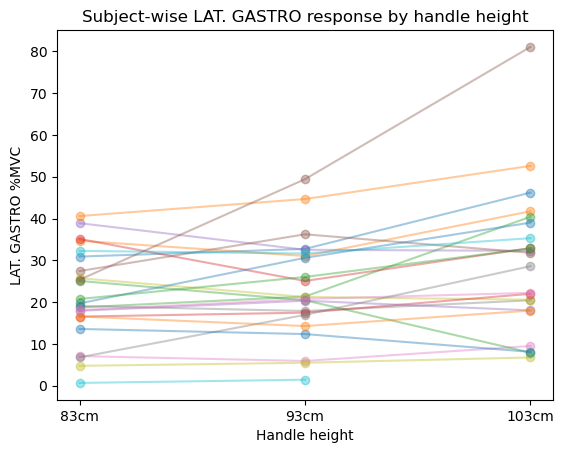

In [39]:
# 피험자별 조건 변화
condition_order = ["83cm", "93cm", "103cm"]

for subject in subject_means["subject"].unique():
    temp = subject_means[subject_means["subject"] == subject]
    temp = temp.set_index("condition").reindex(condition_order)

    plt.plot(
        condition_order,
        temp[value_col],
        marker="o",
        alpha=0.4
    )

plt.xlabel("Handle height")
plt.ylabel("LAT. GASTRO %MVC")
plt.title("Subject-wise LAT. GASTRO response by handle height")
plt.show()

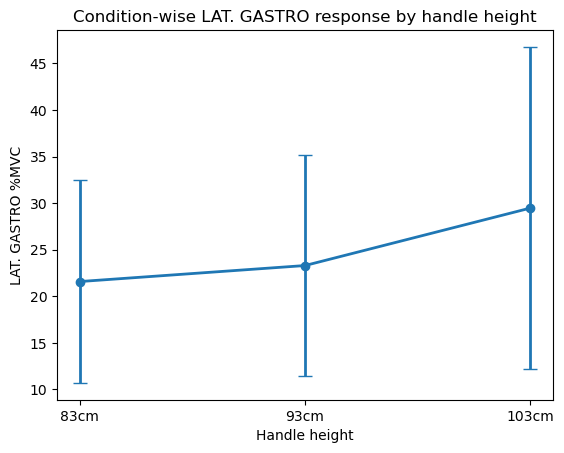

In [40]:
# 조건별 평균 ± SD
summary_plot = condition_summary.reindex(condition_order)
plt.errorbar(condition_order, summary_plot["mean"], yerr=summary_plot["std"], marker="o", linewidth=2, capsize=5)
plt.xlabel("Handle height")
plt.ylabel("LAT. GASTRO %MVC")
plt.title("Condition-wise LAT. GASTRO response by handle height")
plt.show()

## 6. RM-ANOVA용 데이터 구성

반복측정 분산분석에 사용할 수 있도록
피험자별 조건 평균을 기준으로 complete-case 데이터를 구성한다.

세 조건(83cm, 93cm, 103cm)의 값이 모두 존재하는 피험자만 포함한 뒤,
RM-ANOVA 입력에 맞는 long format으로 변환한다.

In [41]:
rm_complete = prepare_rm_complete(subject_means,value_col)
rm_complete

condition,103cm,83cm,93cm
subject,,,
S001,46.208888,30.901020,32.736022
S002,41.734040,34.690921,31.033612
S003,40.417521,18.736805,21.344442
S004,32.930758,35.120224,25.068083
S005,32.265172,38.889636,32.525585
S006,31.796602,27.437259,36.233753
S007,9.506702,7.083490,5.923372
S008,20.443789,19.093113,17.885663
S009,20.578648,25.723002,21.240254


In [42]:
rm_long = prepare_rm_long(rm_complete,value_col)
rm_long

,subject,condition,lat_gastro_percent_mvc
0,S001,83cm,30.901020
1,S002,83cm,34.690921
2,S003,83cm,18.736805
3,S004,83cm,35.120224
4,S005,83cm,38.889636
...,...,...,...
61,S019,103cm,6.764295
62,S020,103cm,35.308122
63,S021,103cm,8.111253
64,S022,103cm,17.985201


In [43]:
len(rm_long)


66

## 7. Repeated Measures ANOVA

같은 피험자가 세 손잡이 높이 조건을 모두 경험한 반복측정 구조이므로
Repeated Measures ANOVA를 사용하여 조건 효과를 검정한다.

In [44]:
anova_results = run_rm_anova(rm_long,value_col)
print(anova_results)

                 Anova
          F Value Num DF  Den DF Pr > F
---------------------------------------
condition  4.9861 2.0000 42.0000 0.0114



## 8. 사후검정 및 다중비교 보정

RM-ANOVA에서 조건 효과가 확인된 뒤,
어떤 조건 간 차이에서 발생한 것인지 확인하기 위해 paired t-test를 수행한다.

세 쌍의 비교에서 발생하는 다중검정 문제를 보정하기 위해
Bonferroni correction을 적용한다.

In [45]:

posthoc_results = run_posthoc(rm_complete)

posthoc_results

,comparison,t,p_raw,p_bonferroni,significant
0,83cm vs 93cm,-1.150157,0.263009,0.789027,False
1,83cm vs 103cm,-2.241973,0.035890,0.107670,False
2,93cm vs 103cm,-2.681999,0.013955,0.041866,True


## 9. 결과 해석

Repeated Measures ANOVA 결과,
손잡이 높이 조건에 따른 LAT. GASTRO %MVC의 차이가 통계적으로 유의하였다
(F(2, 42) = 4.986, p = 0.011).

사후검정에 Bonferroni 보정을 적용한 결과,
93cm와 103cm 조건 간 차이만 통계적으로 유의하였다.

반면 83cm-93cm, 83cm-103cm 비교에서는
Bonferroni 보정 후 유의한 차이가 확인되지 않았다.

따라서 본 분석에서는 손잡이 높이에 따른 LAT. GASTRO 근활성도 차이가 존재하며,
특히 93cm와 103cm 조건 사이에서 차이가 나타난 것으로 해석할 수 있다.